In [1]:
import re
import sys
from pathlib import Path

import h5py
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from tqdm.auto import tqdm

ROOT_PATH = Path().resolve().parents[3]
sys.path.insert(0, str(ROOT_PATH))


In [3]:
# ── Checkpoints ───────────────────────────────────────────────────────
PREFILTER_CKPT = ROOT_PATH / (
    "experiments/numu/"
    "da_prefilter_numu_260429_0155_Qclip_softlabels_PlateauLR_lambda0.05_"
    "MC2M_dmodel128_zflipBothMCExp_SoftFocalLoss/best_da_model.pth"
)
NU_CKPT = ROOT_PATH / (
    "experiments/numu/"
    "260508_1724_da_nu_classifier_h5s0_lambda0.01_thr0.8_seed32/"
    "best_da_model.pth"
)

# ── Data ──────────────────────────────────────────────────────────────
EXP_H5 = ROOT_PATH / "data_manager/data/h5datasets/exp_full.h5"

# ── Devices ───────────────────────────────────────────────────────────
DEVICE_SN = "cuda:4"
DEVICE_PF = "cuda:4"
DEVICE_NU = "cuda:4"

# ── Inference params ──────────────────────────────────────────────────
SN_THRESHOLD   = 0.8
MIN_RAW_HITS   = 5
MIN_SN_HITS    = 8
MIN_SN_STRINGS = 2
BATCH_SIZE     = 512

# ── Analysis thresholds ───────────────────────────────────────────────
PF_THR = 0.6   # prefilter score threshold
NU_THR = 0.8   # nu-classifier score threshold

# ── Cap: set to an int to test on a subset of parts, None = all ───────
N_PARTS_CAP = 1

# ── Broken OM blacklist ───────────────────────────────────────────────
# Rules are applied per-hit, part-level (all events in a part share
# the same cluster and part_key).
# Two rule types:
#   {"channel": ch, "part_key": "part_sYYYY_cCC_rRRRR"}  — specific run only
#   {"channel": ch, "cluster":  N}                        — all runs in cluster N
APPLY_BLACKLIST = True
BLACKLIST = [
    {"channel": 198, "part_key": "part_s2020_c04_r0117"},  # broken OM, single run
    {"channel":  71, "cluster": 4},                         # broken OM, all cluster 4
]

STRING_DIVISOR = 36


In [4]:
from inference_v2.shared.model_utils import load_model, load_sn_model, predict_scores
from gplotnikov_sig_noise_models.k_nsol_labelneq0_da_hs128_k0p0001.sig_noise_model_v3 import (
    predict_flat as _sn_predict_flat,
)
from data_manager.nu_classifier_ds_builder.io import _count_sig_hits_strings

print("Loading SN model ...")
_sn_nn, _sn_cfg, _sn_dev = load_sn_model(device=DEVICE_SN)

print("Loading prefilter model ...")
pf_model, pf_norm, pf_cfg = load_model(str(PREFILTER_CKPT), device=DEVICE_PF)
pf_max_hits   = pf_cfg.get("data", {}).get("max_hits", 500)
pf_with_probs = pf_cfg.get("model", {}).get("input_dim", 5) == 6
print(f"  prefilter  max_hits={pf_max_hits}  with_probs={pf_with_probs}")

print("Loading nu-classifier model ...")
nu_model, nu_norm, nu_cfg = load_model(str(NU_CKPT), device=DEVICE_NU)
nu_max_hits   = nu_cfg.get("data", {}).get("max_hits", 500)
nu_with_probs = nu_cfg.get("model", {}).get("input_dim", 5) == 6
print(f"  nu-classif max_hits={nu_max_hits}  with_probs={nu_with_probs}")

print("\nAll models loaded.")


Loading SN model ...


/home/albert/Baikal2025/gplotnikov_sig_noise_models/k_nsol_labelneq0_da_hs128_k0p0001/model_simplified.py:39: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.num_heads is odd
  self.enc = nn.TransformerEncoder(enc_layer, num_layers)


Loading prefilter model ...
  prefilter  max_hits=500  with_probs=False
Loading nu-classifier model ...
  nu-classif max_hits=500  with_probs=False

All models loaded.


In [5]:
# ── Helpers ───────────────────────────────────────────────────────────
_PART_RE = re.compile(r"part_s(\d+)_c(\d+)_r(\d+)")

def _parse_part_key(pk: str) -> tuple[int, int, int]:
    m = _PART_RE.match(pk)
    return int(m.group(1)), int(m.group(2)), int(m.group(3))

def _make_blacklist_mask(channels: np.ndarray, cluster: int, part_key: str) -> np.ndarray:
    """Return per-hit boolean keep-mask for the current part."""
    if not APPLY_BLACKLIST:
        return np.ones(len(channels), dtype=bool)
    mask = np.ones(len(channels), dtype=bool)
    for rule in BLACKLIST:
        ch = rule["channel"]
        if "part_key" in rule and part_key == rule["part_key"]:
            mask &= channels != ch
        elif "cluster" in rule and cluster == rule["cluster"]:
            mask &= channels != ch
    return mask

# ── Main processing loop ──────────────────────────────────────────────
records = []

with h5py.File(str(EXP_H5), "r") as h5f:
    grp   = h5f["exp_full"]
    parts = sorted(grp["raw"]["data"].keys())
    if N_PARTS_CAP is not None:
        parts = parts[:N_PARTS_CAP]
    print(f"Processing {len(parts)} parts ...")

    for pk in tqdm(parts, desc="parts"):
        ev_starts = grp[f"raw/ev_starts/{pk}/data"][:].astype(np.int64)
        n_events  = len(ev_starts) - 1
        if n_events == 0:
            continue

        data_raw = grp[f"raw/data/{pk}/data"][:].astype(np.float32)
        channels = grp[f"raw/channels/{pk}/data"][:].astype(np.int32)

        season, cluster, run_num = _parse_part_key(pk)

        # ── Apply blacklist (part-level, vectorised) ───────────────────
        bl_mask = _make_blacklist_mask(channels, cluster, pk)
        clean_raw   = data_raw[bl_mask]
        clean_chans = channels[bl_mask]

        # Recompute per-event clean hit counts via cumsum trick
        bl_cum        = np.concatenate([[0], np.cumsum(bl_mask)])
        clean_hit_cnt = (bl_cum[ev_starts[1:]] - bl_cum[ev_starts[:-1]]).astype(np.int32)
        clean_starts  = np.concatenate([[0], np.cumsum(clean_hit_cnt.astype(np.int64))]).astype(np.int64)

        # ── Prefilter on clean raw hits ────────────────────────────────
        pf_eligible    = np.where(clean_hit_cnt >= MIN_RAW_HITS)[0]
        pf_scores_part = np.full(n_events, np.nan, dtype=np.float32)

        if len(pf_eligible) > 0:
            pf_feats = [clean_raw[int(clean_starts[ei]):int(clean_starts[ei+1])]
                        for ei in pf_eligible]
            pf_scores_part[pf_eligible] = predict_scores(
                pf_model, pf_feats, pf_norm,
                batch_size=BATCH_SIZE, max_hits=pf_max_hits,
                device=DEVICE_PF, feats_with_probs=pf_with_probs,
                with_tqdm=False,
            )

        # ── SN model on clean raw hits ─────────────────────────────────
        if len(clean_raw) == 0:
            n_sn_h = np.zeros(n_events, dtype=np.int32)
            n_sn_s = np.zeros(n_events, dtype=np.int32)
        else:
            sn_probs = _sn_predict_flat(
                _sn_nn, clean_raw, clean_starts,
                batch_size=BATCH_SIZE, device=torch.device(_sn_dev),
                normalize=True, desc="",
            )
            sn_mask = sn_probs >= SN_THRESHOLD
            n_sn_h, n_sn_s = _count_sig_hits_strings(
                sn_mask, clean_chans,
                clean_starts[:-1].astype(np.int64),
                clean_hit_cnt, n_events,
            )

        # ── Nu-classifier on SN-filtered hits ─────────────────────────
        nu_eligible    = np.where((n_sn_h >= MIN_SN_HITS) & (n_sn_s >= MIN_SN_STRINGS))[0]
        nu_scores_part = np.full(n_events, np.nan, dtype=np.float32)

        if len(nu_eligible) > 0:
            nu_feats = []
            for ei in nu_eligible:
                s, e    = int(clean_starts[ei]), int(clean_starts[ei + 1])
                ev_mask = sn_mask[s:e]
                nu_feats.append(clean_raw[s:e][ev_mask])
            nu_scores_part[nu_eligible] = predict_scores(
                nu_model, nu_feats, nu_norm,
                batch_size=BATCH_SIZE, max_hits=nu_max_hits,
                device=DEVICE_NU, feats_with_probs=nu_with_probs,
                with_tqdm=False,
            )

        # ── Collect results (only events with at least a prefilter score)
        for ei in pf_eligible:
            records.append({
                "part_key":        pk,
                "local_idx":       int(ei),
                "season":          season,
                "cluster":         cluster,
                "run_num":         run_num,
                "n_raw_hits":      int(clean_hit_cnt[ei]),
                "n_sn_hits":       int(n_sn_h[ei]),
                "n_sn_strings":    int(n_sn_s[ei]),
                "prefilter_score": float(pf_scores_part[ei]),
                "nu_score":        float(nu_scores_part[ei]) if not np.isnan(nu_scores_part[ei]) else np.nan,
            })

df_scores = pd.DataFrame(records)
df_both   = df_scores.dropna(subset=["nu_score"]).copy()   # events with both scores

print(f"\nEvents with prefilter score: {len(df_scores):,}")
print(f"Events with both scores:      {len(df_both):,}  "
      f"(passed SN quality: n_sn_hits>={MIN_SN_HITS}, n_sn_strings>={MIN_SN_STRINGS})")
print(f"\nPrefilter score > {PF_THR}:  "
      f"{(df_scores.prefilter_score > PF_THR).sum():,}  "
      f"({100*(df_scores.prefilter_score > PF_THR).mean():.2f}%)")
print(f"Nu score > {NU_THR}:  "
      f"{(df_both.nu_score > NU_THR).sum():,}  "
      f"({100*(df_both.nu_score > NU_THR).mean():.2f}%  of events with nu score)")
df_scores.head(3)


Processing 1 parts ...


parts:   0%|          | 0/1 [00:00<?, ?it/s]

/home/albert/miniconda3/envs/baikal25/lib/python3.10/site-packages/torch/nn/modules/transformer.py:531: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. We recommend specifying layout=torch.jagged when constructing a nested tensor, as this layout receives active development, has better operator coverage, and works with torch.compile. (Triggered internally at /pytorch/aten/src/ATen/NestedTensorImpl.cpp:178.)
  output = torch._nested_tensor_from_mask(



Events with prefilter score: 3,211,818
Events with both scores:      113,699  (passed SN quality: n_sn_hits>=8, n_sn_strings>=2)

Prefilter score > 0.6:  4,640  (0.14%)
Nu score > 0.8:  110  (0.10%  of events with nu score)


,part_key,local_idx,season,cluster,run_num,n_raw_hits,n_sn_hits,n_sn_strings,prefilter_score,nu_score
0,part_s2020_c02_r0020,0,2020,2,20,42,0,0,0.014370,NaN
1,part_s2020_c02_r0020,1,2020,2,20,39,1,1,0.293039,NaN
2,part_s2020_c02_r0020,2,2020,2,20,50,2,1,0.055303,NaN


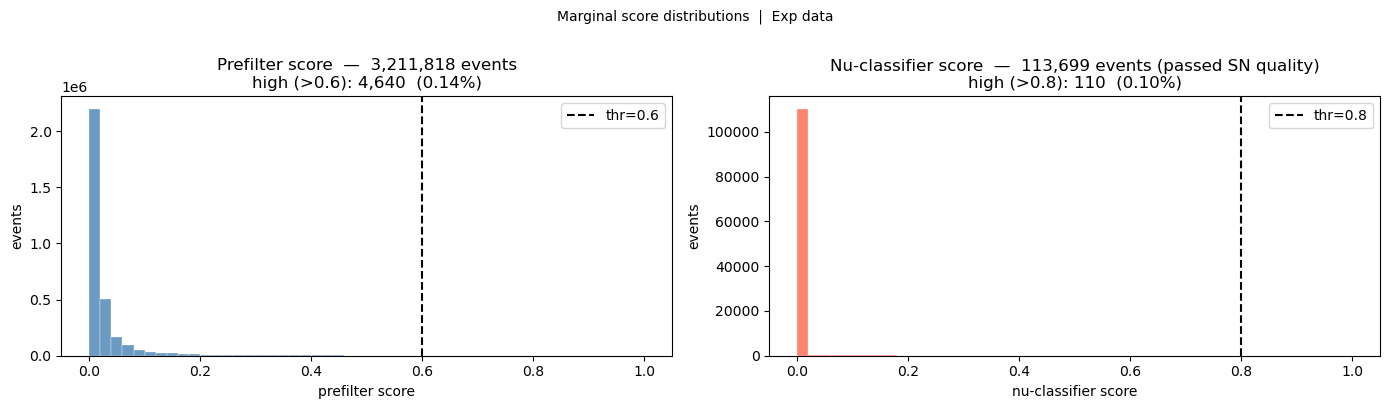

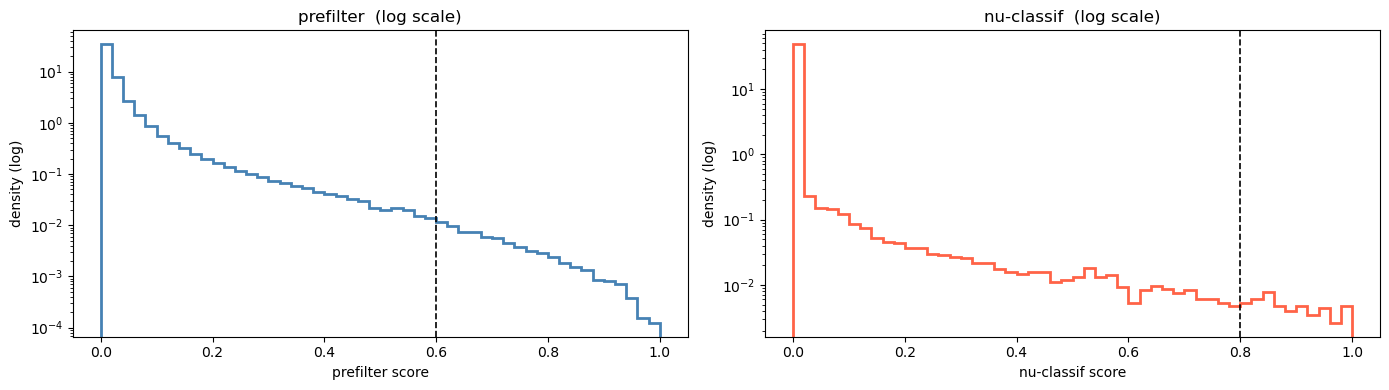

In [6]:
# ── Marginal score distributions ──────────────────────────────────────
bins_pf = np.linspace(0, 1, 51)
bins_nu = np.linspace(0, 1, 51)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

ax = axes[0]
ax.hist(df_scores.prefilter_score, bins=bins_pf, color="steelblue",
        alpha=0.8, edgecolor="white", linewidth=0.3)
ax.axvline(PF_THR, color="black", lw=1.5, ls="--", label=f"thr={PF_THR}")
hi_pf = (df_scores.prefilter_score > PF_THR).sum()
ax.set_title(
    f"Prefilter score  —  {len(df_scores):,} events\n"
    f"high (>{PF_THR}): {hi_pf:,}  ({100*hi_pf/len(df_scores):.2f}%)"
)
ax.set_xlabel("prefilter score"); ax.set_ylabel("events"); ax.legend()

ax = axes[1]
ax.hist(df_both.nu_score, bins=bins_nu, color="tomato",
        alpha=0.8, edgecolor="white", linewidth=0.3)
ax.axvline(NU_THR, color="black", lw=1.5, ls="--", label=f"thr={NU_THR}")
hi_nu = (df_both.nu_score > NU_THR).sum()
ax.set_title(
    f"Nu-classifier score  —  {len(df_both):,} events (passed SN quality)\n"
    f"high (>{NU_THR}): {hi_nu:,}  ({100*hi_nu/len(df_both):.2f}%)"
)
ax.set_xlabel("nu-classifier score"); ax.set_ylabel("events"); ax.legend()

plt.suptitle("Marginal score distributions  |  Exp data", fontsize=10, y=1.01)
plt.tight_layout(); plt.show()

# log-scale overlay
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
kw = dict(density=True, histtype="step", linewidth=2)
for ax, col, thr, bins, color, label in [
    (axes[0], "prefilter_score", PF_THR, bins_pf, "steelblue", "prefilter"),
    (axes[1], "nu_score",        NU_THR, bins_nu, "tomato",    "nu-classif"),
]:
    data = df_both[col] if col == "nu_score" else df_scores[col]
    ax.hist(data, bins=bins, color=color, **kw)
    ax.axvline(thr, color="black", lw=1.2, ls="--")
    ax.set_yscale("log"); ax.set_xlabel(f"{label} score"); ax.set_ylabel("density (log)")
    ax.set_title(f"{label}  (log scale)")
plt.tight_layout(); plt.show()


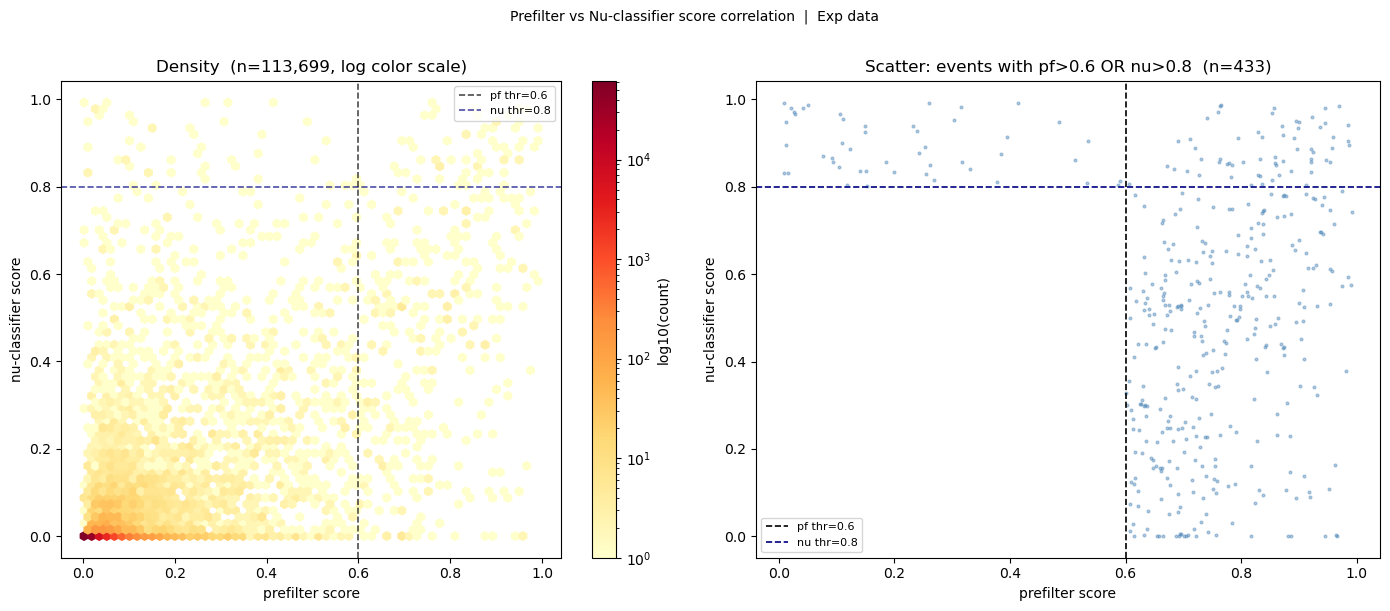

Quadrant summary (events with both scores):
  pf>thr & nu>thr  (both high):               62  (0.05%)
  pf>thr & nu<=thr (pf high, nu low):         323  (0.28%)
  pf<=thr & nu>thr (nu high, pf low):          48  (0.04%)
  pf<=thr & nu<=thr (both low):            113,266  (99.62%)


In [7]:
# ── 2D correlation: prefilter_score vs nu_score ────────────────────────
# Uses only events that have both scores.

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Hexbin density
ax = axes[0]
hb = ax.hexbin(df_both.prefilter_score, df_both.nu_score,
               gridsize=60, cmap="YlOrRd", mincnt=1, bins="log")
ax.axvline(PF_THR, color="black", lw=1.2, ls="--", alpha=0.7, label=f"pf thr={PF_THR}")
ax.axhline(NU_THR, color="navy",  lw=1.2, ls="--", alpha=0.7, label=f"nu thr={NU_THR}")
ax.set_xlabel("prefilter score"); ax.set_ylabel("nu-classifier score")
ax.set_title(f"Density  (n={len(df_both):,}, log color scale)")
ax.legend(fontsize=8); plt.colorbar(hb, ax=ax, label="log10(count)")

# Scatter of high-score events (nu > NU_THR or pf > PF_THR)
ax = axes[1]
mask_any_hi = (df_both.prefilter_score > PF_THR) | (df_both.nu_score > NU_THR)
sub = df_both[mask_any_hi]
ax.scatter(sub.prefilter_score, sub.nu_score, s=4, alpha=0.4, color="steelblue", rasterized=True)
ax.axvline(PF_THR, color="black", lw=1.2, ls="--", label=f"pf thr={PF_THR}")
ax.axhline(NU_THR, color="navy",  lw=1.2, ls="--", label=f"nu thr={NU_THR}")
ax.set_xlabel("prefilter score"); ax.set_ylabel("nu-classifier score")
ax.set_title(f"Scatter: events with pf>{PF_THR} OR nu>{NU_THR}  (n={len(sub):,})")
ax.legend(fontsize=8)

plt.suptitle("Prefilter vs Nu-classifier score correlation  |  Exp data", fontsize=10, y=1.01)
plt.tight_layout(); plt.show()

# Quadrant counts
q_hh = ((df_both.prefilter_score > PF_THR) & (df_both.nu_score > NU_THR)).sum()
q_lh = ((df_both.prefilter_score <= PF_THR) & (df_both.nu_score > NU_THR)).sum()
q_hl = ((df_both.prefilter_score > PF_THR) & (df_both.nu_score <= NU_THR)).sum()
q_ll = ((df_both.prefilter_score <= PF_THR) & (df_both.nu_score <= NU_THR)).sum()
n    = len(df_both)
print("Quadrant summary (events with both scores):")
print(f"  pf>thr & nu>thr  (both high):           {q_hh:6,}  ({100*q_hh/n:.2f}%)")
print(f"  pf>thr & nu<=thr (pf high, nu low):      {q_hl:6,}  ({100*q_hl/n:.2f}%)")
print(f"  pf<=thr & nu>thr (nu high, pf low):      {q_lh:6,}  ({100*q_lh/n:.2f}%)")
print(f"  pf<=thr & nu<=thr (both low):            {q_ll:6,}  ({100*q_ll/n:.2f}%)")


Nu-classifier high (>0.8): 110 events
  of these, prefilter_score > 0.6: 62  (56.4%)
  prefilter_score mean:   0.570
  prefilter_score median: 0.724


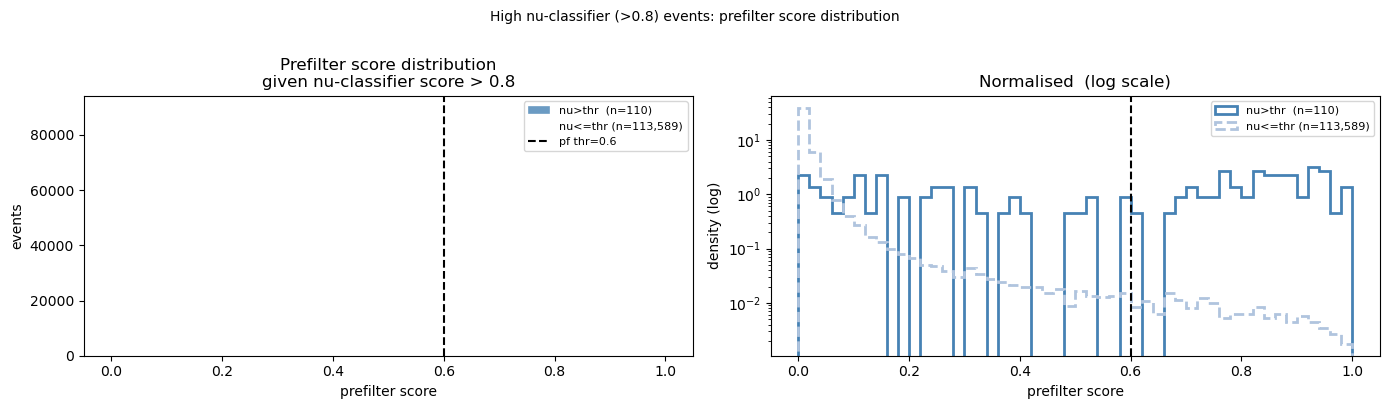


Nu-high but prefilter-low events: 48
  By cluster:
cluster
2    48

  Top 10 runs by count:
run_num
20    48


In [8]:
# ── Question 1: events with high nu-classifier score — what does prefilter say? ──
nu_hi = df_both[df_both.nu_score > NU_THR]
nu_lo = df_both[df_both.nu_score <= NU_THR]

print(f"Nu-classifier high (>{NU_THR}): {len(nu_hi):,} events")
print(f"  of these, prefilter_score > {PF_THR}: "
      f"{(nu_hi.prefilter_score > PF_THR).sum():,}  "
      f"({100*(nu_hi.prefilter_score > PF_THR).mean():.1f}%)")
print(f"  prefilter_score mean:   {nu_hi.prefilter_score.mean():.3f}")
print(f"  prefilter_score median: {nu_hi.prefilter_score.median():.3f}")

bins = np.linspace(0, 1, 51)
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

ax = axes[0]
ax.hist(nu_hi.prefilter_score, bins=bins, color="steelblue",
        alpha=0.8, edgecolor="white", linewidth=0.3, label=f"nu>thr  (n={len(nu_hi):,})")
ax.hist(nu_lo.prefilter_score, bins=bins, color="lightblue",
        alpha=0.6, edgecolor="white", linewidth=0.3, linestyle="--",
        histtype="step", label=f"nu<=thr (n={len(nu_lo):,})")
ax.axvline(PF_THR, color="black", lw=1.5, ls="--", label=f"pf thr={PF_THR}")
ax.set_xlabel("prefilter score"); ax.set_ylabel("events")
ax.set_title(f"Prefilter score distribution\ngiven nu-classifier score > {NU_THR}")
ax.legend(fontsize=8)

ax = axes[1]
ax.hist(nu_hi.prefilter_score, bins=bins, color="steelblue", density=True,
        histtype="step", linewidth=2, label=f"nu>thr  (n={len(nu_hi):,})")
ax.hist(nu_lo.prefilter_score, bins=bins, color="lightsteelblue", density=True,
        histtype="step", linewidth=2, linestyle="--", label=f"nu<=thr (n={len(nu_lo):,})")
ax.axvline(PF_THR, color="black", lw=1.5, ls="--")
ax.set_yscale("log"); ax.set_xlabel("prefilter score"); ax.set_ylabel("density (log)")
ax.set_title("Normalised  (log scale)"); ax.legend(fontsize=8)

plt.suptitle(
    f"High nu-classifier (>{NU_THR}) events: prefilter score distribution",
    fontsize=10, y=1.01,
)
plt.tight_layout(); plt.show()

# Metadata: which clusters/runs produce nu-high pf-low events?
nu_hi_pf_lo = nu_hi[nu_hi.prefilter_score <= PF_THR]
if len(nu_hi_pf_lo) > 0:
    print(f"\nNu-high but prefilter-low events: {len(nu_hi_pf_lo):,}")
    print("  By cluster:")
    print(nu_hi_pf_lo.groupby("cluster").size().sort_values(ascending=False).to_string())
    print("\n  Top 10 runs by count:")
    print(nu_hi_pf_lo.groupby("run_num").size().sort_values(ascending=False).head(10).to_string())


Prefilter high (>0.6): 4,640 events
  of these, passed SN quality (have nu score): 385
  of these, failed SN quality (no nu score):   4,255
  among those with nu score:
    nu_score > 0.8: 62  (16.1%)
    nu_score mean:   0.482
    nu_score median: 0.511


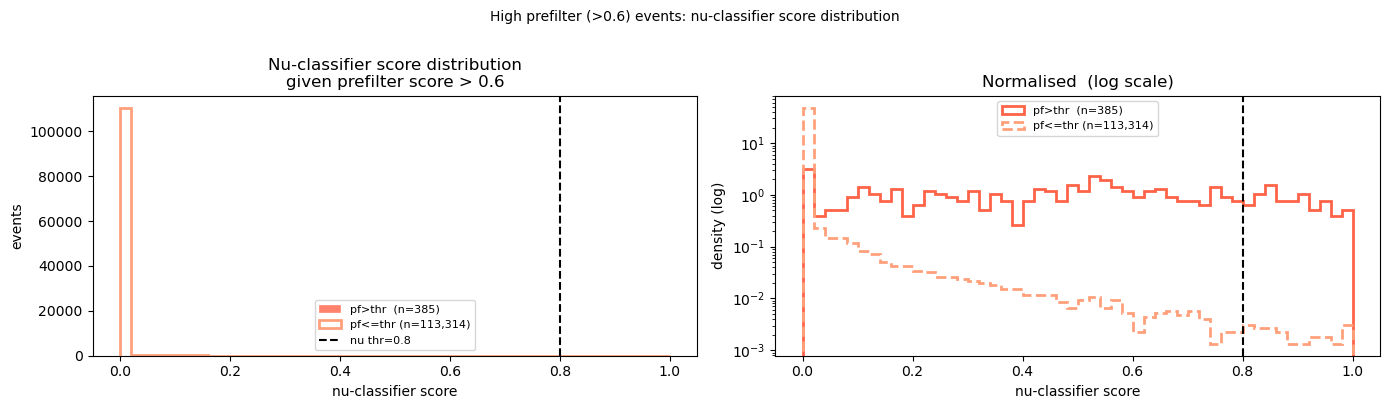


Prefilter-high but nu-low events: 323
  By cluster:
cluster
2    323

  Top 10 runs by count:
run_num
20    323


In [9]:
# ── Question 2: events with high prefilter score — what does nu-classifier say? ──
pf_hi_all  = df_scores[df_scores.prefilter_score > PF_THR]                # all pf-high events
pf_hi_both = df_both[df_both.prefilter_score > PF_THR]                    # subset with nu score
pf_lo_both = df_both[df_both.prefilter_score <= PF_THR]

n_pf_hi_no_nu = len(pf_hi_all) - len(pf_hi_both)  # failed SN quality cut

print(f"Prefilter high (>{PF_THR}): {len(pf_hi_all):,} events")
print(f"  of these, passed SN quality (have nu score): {len(pf_hi_both):,}")
print(f"  of these, failed SN quality (no nu score):   {n_pf_hi_no_nu:,}")
if len(pf_hi_both) > 0:
    print(f"  among those with nu score:")
    print(f"    nu_score > {NU_THR}: "
          f"{(pf_hi_both.nu_score > NU_THR).sum():,}  "
          f"({100*(pf_hi_both.nu_score > NU_THR).mean():.1f}%)")
    print(f"    nu_score mean:   {pf_hi_both.nu_score.mean():.3f}")
    print(f"    nu_score median: {pf_hi_both.nu_score.median():.3f}")

bins = np.linspace(0, 1, 51)
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

ax = axes[0]
if len(pf_hi_both) > 0:
    ax.hist(pf_hi_both.nu_score, bins=bins, color="tomato",
            alpha=0.8, edgecolor="white", linewidth=0.3,
            label=f"pf>thr  (n={len(pf_hi_both):,})")
ax.hist(pf_lo_both.nu_score, bins=bins, color="lightsalmon",
        histtype="step", linewidth=2, density=False,
        label=f"pf<=thr (n={len(pf_lo_both):,})")
ax.axvline(NU_THR, color="black", lw=1.5, ls="--", label=f"nu thr={NU_THR}")
ax.set_xlabel("nu-classifier score"); ax.set_ylabel("events")
ax.set_title(f"Nu-classifier score distribution\ngiven prefilter score > {PF_THR}")
ax.legend(fontsize=8)

ax = axes[1]
for data, label, color, ls in [
    (pf_hi_both.nu_score, f"pf>thr  (n={len(pf_hi_both):,})",  "tomato",      "-"),
    (pf_lo_both.nu_score, f"pf<=thr (n={len(pf_lo_both):,})", "lightsalmon", "--"),
]:
    if len(data) > 0:
        ax.hist(data, bins=bins, color=color, density=True,
                histtype="step", linewidth=2, linestyle=ls, label=label)
ax.axvline(NU_THR, color="black", lw=1.5, ls="--")
ax.set_yscale("log"); ax.set_xlabel("nu-classifier score"); ax.set_ylabel("density (log)")
ax.set_title("Normalised  (log scale)"); ax.legend(fontsize=8)

plt.suptitle(
    f"High prefilter (>{PF_THR}) events: nu-classifier score distribution",
    fontsize=10, y=1.01,
)
plt.tight_layout(); plt.show()

# Metadata: which clusters/runs produce pf-high nu-low events?
pf_hi_nu_lo = pf_hi_both[pf_hi_both.nu_score <= NU_THR]
if len(pf_hi_nu_lo) > 0:
    print(f"\nPrefilter-high but nu-low events: {len(pf_hi_nu_lo):,}")
    print("  By cluster:")
    print(pf_hi_nu_lo.groupby("cluster").size().sort_values(ascending=False).to_string())
    print("\n  Top 10 runs by count:")
    print(pf_hi_nu_lo.groupby("run_num").size().sort_values(ascending=False).head(10).to_string())


Events per quadrant:
  Both high   (pf>0.6, nu>0.8): 62  (0.05%)
  PF high, NU low  (pf>0.6, nu<=0.8): 323  (0.28%)
  NU high, PF low  (pf<=0.6, nu>0.8): 48  (0.04%)
  Both low    (pf<=0.6, nu<=0.8): 113,266  (99.62%)


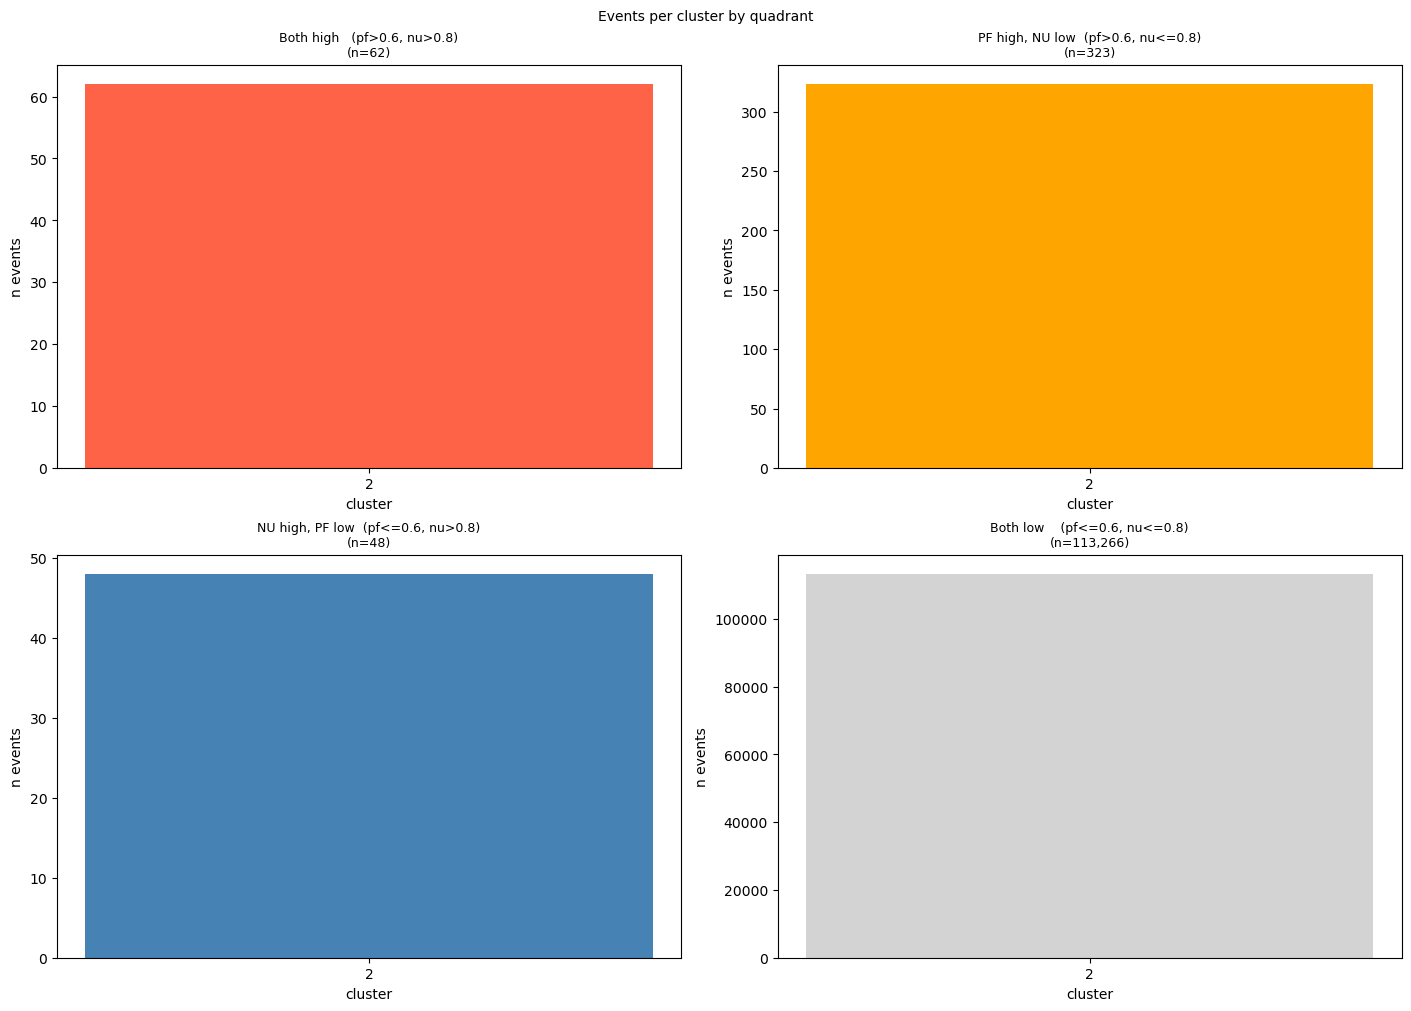


── NU high, PF low  (pf<=0.6, nu>0.8) ── top runs:
  absolute count:
run_num
20    48
  fraction of all events in run:
run_num
20    0.000015

── PF high, NU low  (pf>0.6, nu<=0.8) ── top runs:
  absolute count:
run_num
20    323
  fraction of all events in run:
run_num
20    0.000101


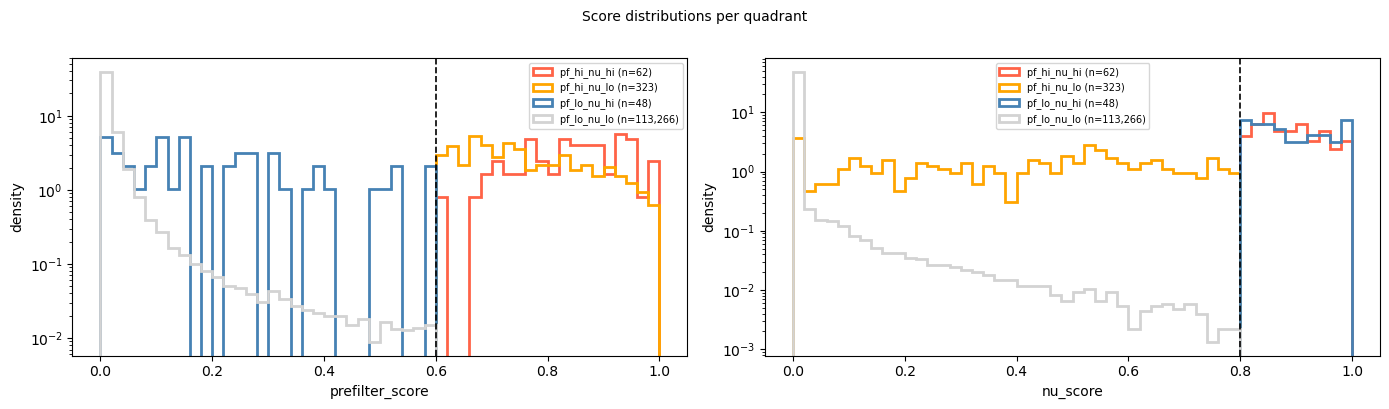

In [10]:
# ── Quadrant deep-dive: metadata breakdown ────────────────────────────
# 4 quadrants defined by (pf_score > PF_THR) x (nu_score > NU_THR)

df_q = df_both.copy()
df_q["pf_hi"] = df_q.prefilter_score > PF_THR
df_q["nu_hi"] = df_q.nu_score > NU_THR
df_q["quadrant"] = df_q.apply(
    lambda r: ("pf_hi" if r.pf_hi else "pf_lo") + "_" + ("nu_hi" if r.nu_hi else "nu_lo"),
    axis=1,
)
QUADRANT_LABELS = {
    "pf_hi_nu_hi": f"Both high   (pf>{PF_THR}, nu>{NU_THR})",
    "pf_hi_nu_lo": f"PF high, NU low  (pf>{PF_THR}, nu<={NU_THR})",
    "pf_lo_nu_hi": f"NU high, PF low  (pf<={PF_THR}, nu>{NU_THR})",
    "pf_lo_nu_lo": f"Both low    (pf<={PF_THR}, nu<={NU_THR})",
}
QUADRANT_COLORS = {
    "pf_hi_nu_hi": "tomato",
    "pf_hi_nu_lo": "orange",
    "pf_lo_nu_hi": "steelblue",
    "pf_lo_nu_lo": "lightgrey",
}

print("Events per quadrant:")
for qk, ql in QUADRANT_LABELS.items():
    n = (df_q.quadrant == qk).sum()
    print(f"  {ql}: {n:,}  ({100*n/len(df_q):.2f}%)")

# ── Cluster breakdown per quadrant ────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10), constrained_layout=True)
for ax, (qk, ql) in zip(axes.flatten(), QUADRANT_LABELS.items()):
    sub = df_q[df_q.quadrant == qk]
    if len(sub) == 0:
        ax.set_visible(False)
        continue
    by_clust = sub.groupby("cluster").size().sort_index()
    ax.bar(by_clust.index.astype(str), by_clust.values, color=QUADRANT_COLORS[qk])
    ax.set_xlabel("cluster"); ax.set_ylabel("n events")
    ax.set_title(f"{ql}\n(n={len(sub):,})", fontsize=9)
plt.suptitle("Events per cluster by quadrant", fontsize=10)
plt.show()

# ── Top runs per "interesting" quadrant ───────────────────────────────
for qk in ("pf_lo_nu_hi", "pf_hi_nu_lo"):
    sub = df_q[df_q.quadrant == qk]
    if len(sub) == 0:
        continue
    print(f"\n── {QUADRANT_LABELS[qk]} ── top runs:")
    top_runs = sub.groupby("run_num").size().sort_values(ascending=False).head(15)
    total_per_run = df_scores.groupby("run_num").size()
    frac = (top_runs / total_per_run).dropna().sort_values(ascending=False)
    print("  absolute count:")
    print(top_runs.to_string())
    print("  fraction of all events in run:")
    print(frac.head(10).to_string())

# ── Score distributions within each quadrant ─────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
bins_pf = np.linspace(0, 1, 51); bins_nu = np.linspace(0, 1, 51)
for ax, col, bins, thr in [
    (axes[0], "prefilter_score", bins_pf, PF_THR),
    (axes[1], "nu_score",        bins_nu, NU_THR),
]:
    for qk, ql in QUADRANT_LABELS.items():
        sub = df_q[df_q.quadrant == qk][col]
        if len(sub) == 0:
            continue
        ax.hist(sub, bins=bins, color=QUADRANT_COLORS[qk], density=True,
                histtype="step", linewidth=2, label=f"{qk} (n={len(sub):,})")
    ax.axvline(thr, color="black", lw=1.2, ls="--")
    ax.set_xlabel(col); ax.set_ylabel("density")
    ax.set_yscale("log"); ax.legend(fontsize=7)
plt.suptitle("Score distributions per quadrant", fontsize=10, y=1.01)
plt.tight_layout(); plt.show()
